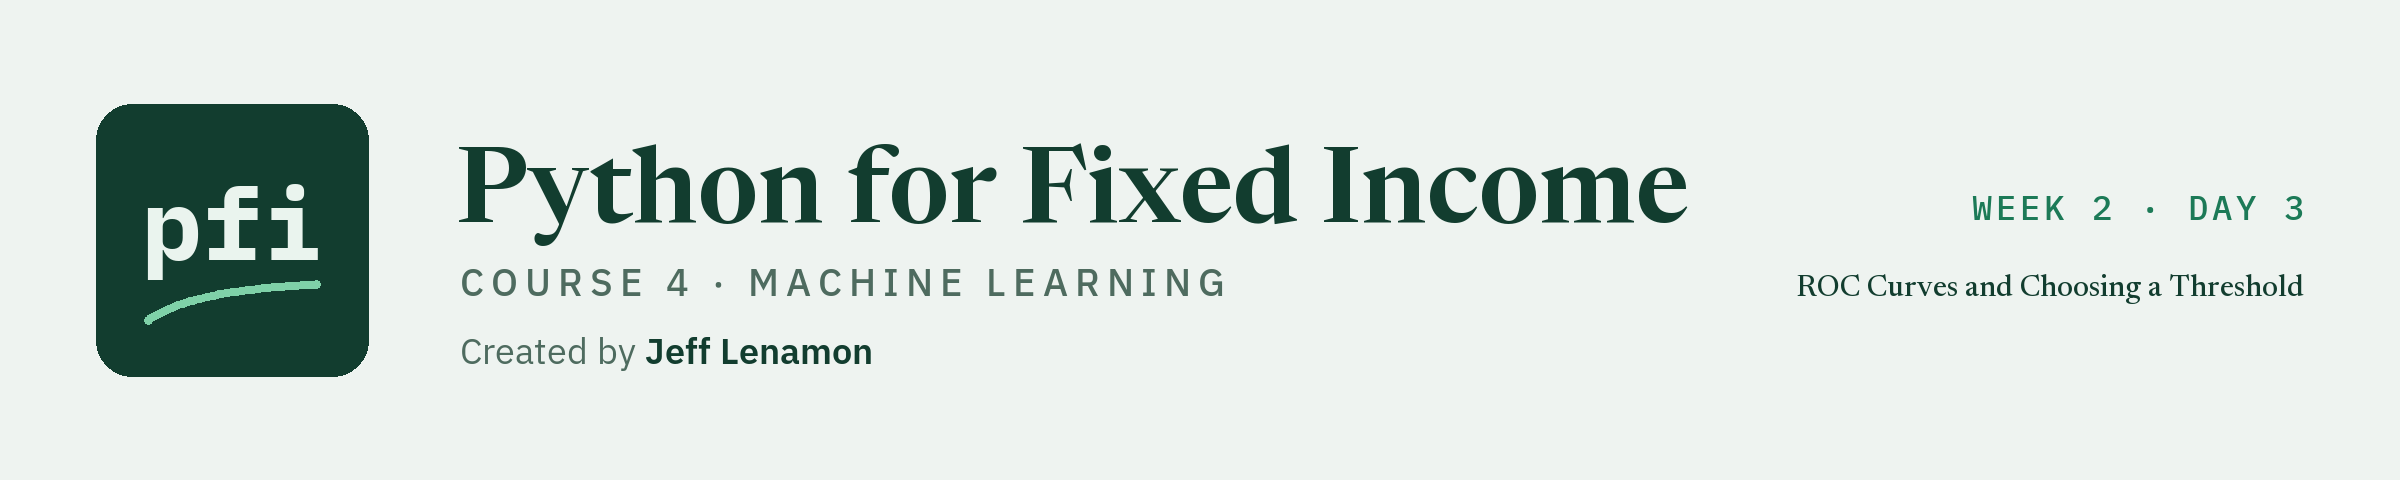

# ROC Curves and Choosing a Threshold

Week 2, Day 3. A probability becomes a flag only at a threshold. Today: every threshold at once in the ROC curve, AUC and what it does not say, the precision-recall curve, choosing a threshold on validation rows by the course's stated rule, and one calibration chart.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week2/day3/08_roc_curves_and_choosing_a_threshold.ipynb)

Day 7 turned the model's probabilities into flags at a threshold of 0.5 and read the confusion matrix. On the 6,000 validation rows it flagged 447 accounts and caught 324 of the 1,327 that defaulted: a recall of 0.2442. Most defaults went unflagged, and nothing about 0.5 says it is the right place to stop.

Today the threshold moves. Every threshold gives its own confusion matrix, so instead of one matrix you will look at all of them at once, measure how well the model **ranks** accounts before any threshold is chosen, and then choose one threshold by a rule written down in advance, on rows that will not be used to report.

**The data is real.** `credit_card_default.csv` is the UCI file Course 1 described in notebook 16: 30,000 credit card accounts in Taiwan, with payment records from April to September 2005 and an outcome for the following month. Consumer credit in Taiwan in 2005 differs from US credit today, and nothing here describes any other market, lender, or period.

**People's attributes are never features.** The file has four columns that describe people: `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE`. No model in this course uses them. The course describes a file and builds no lending rule; a model that used them would sort people by them; and leaving them out does not make a model neutral, because other columns can carry the same information. Day 10 comes back to this once, with counts. As notebook 16 put it: differences between groups in this file do not explain themselves, and they are not a basis for treating people differently.

**The split, as every day this week.** 60 percent training rows fit the model, 20 percent validation rows choose (today: the threshold), and 20 percent test rows are put away until day 10, when they are opened once to report.

**What the model's output is called.** The model probability of default in this file; an account is **flagged at threshold t** when its probability is at least t; the probability is also the model's score. It is never a credit decision, an approval, a lending policy, or a risk grade for a real person. Every threshold and recall target today is a teaching convention, not a statement of what a lender does or should do.

Today you will:

1. Build the ROC curve by hand at six thresholds, then for every threshold with `roc_curve`.
2. Read AUC as a ranking measure, prove it on every pair of accounts, and list what it does not say.
3. Draw the precision-recall curve and compute average precision.
4. Write `threshold_for_recall` and choose a threshold on the validation rows, with Youden's J beside it.
5. See why the rows that choose a threshold cannot also report it.
6. Draw one calibration chart: does a probability of 0.3 mean three in ten?

Q. Set up today's work folder: the thread settings, the seed, today's data files, and the module as day 7 left it.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_08_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv", "credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_08_z7a3hm3i, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv, credit_card_default.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)


from sklearn.linear_model import LogisticRegression

CARD_TARGET = "default payment next month"


def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, with LIMIT_BAL also in units of 10,000 NT dollars."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    card["LIMIT_BAL_10k"] = card["LIMIT_BAL"] / 10_000
    return card


def test_logistic_probability_hand_values():
    assert mlkit.logistic_probability(0.0) == pytest.approx(0.5, abs=1e-12)
    # log-odds of ln 3 are odds of 3 to 1, a probability of 0.75
    assert mlkit.logistic_probability(np.log(3)) == pytest.approx(0.75, abs=1e-12)
    probabilities = mlkit.logistic_probability(np.array([-np.log(3), 0.0]))
    assert probabilities == pytest.approx([0.25, 0.5], abs=1e-12)


def test_odds_ratios_exp():
    coefficients = pd.Series({"const": -1.4, "PAY_0": np.log(2.0), "LIMIT_BAL_10k": 0.0})
    ratios = mlkit.odds_ratios(coefficients)
    assert list(ratios.index) == ["PAY_0", "LIMIT_BAL_10k"]
    assert ratios["PAY_0"] == pytest.approx(2.0, abs=1e-12)
    assert ratios["LIMIT_BAL_10k"] == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds_ratios(pd.Series({"const": 1.0}))


@pytest.mark.parametrize("model, features", [
    ("d06_logit_default_on_pay0", ["PAY_0"]),
    ("d06_logit_default_on_pay0_limit10k", ["PAY_0", "LIMIT_BAL_10k"]),
])
def test_logit_matches_excel_solver_reference(model, features):
    card = read_card()
    logit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features]))
    fit = logit.fit(disp=0)
    # Excel Solver, non-negative box off, maximising the summed log-likelihood column
    solver = pd.Series({name: excel(f"{model}:coef_{name}") for name in ["const"] + features})
    for name in solver.index:
        assert fit.params[name] == pytest.approx(solver[name], abs=1e-4), name
    # the log-likelihood Excel summed, at Excel's own coefficients
    assert logit.loglike(solver[fit.params.index].to_numpy()) == pytest.approx(excel(f"{model}:loglik"), abs=1e-6)
    # Excel: =EXP(coef) as an odds ratio
    for name, ratio in mlkit.odds_ratios(solver).items():
        assert ratio == pytest.approx(excel(f"{model}:odds_ratio_{name}"), abs=1e-12)


@pytest.mark.parametrize("features", [["PAY_0"], ["PAY_0", "LIMIT_BAL_10k"]])
def test_sklearn_cinf_matches_statsmodels(features):
    card = read_card()
    fit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features])).fit(disp=0)
    # C=np.inf switches the default L2 penalty off; penalty= is never used (deprecated in scikit-learn 1.8).
    # tol=1e-8: with the default tol=1e-4 the solver stops 2.2e-4 away on PAY_0 alone
    model = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(card[features], card[CARD_TARGET])
    assert model.intercept_[0] == pytest.approx(fit.params["const"], abs=1e-4)
    for name, value in zip(features, model.coef_[0]):
        assert value == pytest.approx(fit.params[name], abs=1e-4), name


from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


def pay0_flags(threshold: float = 0.5) -> tuple[pd.Series, np.ndarray]:
    """Actual defaults and flags of the logistic model on PAY_0, at Excel Solver's coefficients."""
    card = read_card()
    model = "d06_logit_default_on_pay0"
    z = excel(f"{model}:coef_const") + excel(f"{model}:coef_PAY_0") * card["PAY_0"]
    return card[CARD_TARGET], (mlkit.logistic_probability(z) >= threshold).astype(int)


def test_confusion_counts_hand():
    counts = mlkit.confusion_counts([0, 0, 1, 1, 1, 0], [0, 1, 1, 0, 1, 0])
    assert counts == {"tn": 2, "fp": 1, "fn": 1, "tp": 2}


def test_confusion_counts_match_sklearn():
    y, flags = pay0_flags()
    counts = mlkit.confusion_counts(y, flags)
    tn, fp, fn, tp = confusion_matrix(y, flags).ravel()
    assert counts == {"tn": tn, "fp": fp, "fn": fn, "tp": tp}
    # Excel: =COUNTIFS(actual, 1, probability, ">=0.5") and the other three
    for name, value in counts.items():
        assert value == excel(f"d07_confusion_pay0_at_0.5:{name}")


def test_metrics_match_sklearn():
    y, flags = pay0_flags()
    metrics = mlkit.classification_metrics(y, flags)
    assert metrics["accuracy"] == pytest.approx(accuracy_score(y, flags), abs=1e-12)
    assert metrics["precision"] == pytest.approx(precision_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["recall"] == pytest.approx(recall_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["f1"] == pytest.approx(f1_score(y, flags, zero_division=0), abs=1e-12)
    for name in ("accuracy", "precision", "recall", "f1"):
        assert metrics[name] == pytest.approx(excel(f"d07_confusion_pay0_at_0.5:{name}"), abs=1e-12)


def test_metrics_zero_division():
    # a model that flags nothing: precision, recall, and F1 are 0 by convention, not an error
    metrics = mlkit.classification_metrics([0, 1, 1, 0], [0, 0, 0, 0])
    assert metrics == {"accuracy": 0.5, "precision": 0.0, "recall": 0.0, "f1": 0.0}


def test_rejects_labels_other_than_0_1():
    with pytest.raises(ValueError, match="other than 0 and 1"):
        mlkit.confusion_counts([0, 1, 2], [0, 1, 1])
    with pytest.raises(ValueError):
        mlkit.classification_metrics([0, 1], [True, 0.5])

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients', 'odds_ratios', 'logistic_probability', 'confusion_counts', 'classification_metrics']


* The module and its tests are written as they stood at the end of day 7, so this notebook runs on its own even if you skipped a day.

## Where Day 7 Left Off

Q. Load the card file and count the defaults.

The accounts are real, in Taiwan, in 2005. This is description of the whole file, as in Course 1; no number from it is used to build the model.

In [5]:
# the 30,000 UCI card accounts
card = pd.read_csv("credit_card_default.csv")
target = "default payment next month"

print(f"{len(card):,} accounts, {card.shape[1]} columns; {card[target].sum():,} defaulted the following month "
      f"({card[target].mean():.2%})")

30,000 accounts, 25 columns; 6,636 defaulted the following month (22.12%)


* 6,636 of 30,000 accounts, 22.12%: the rate Course 1 found.

Q. Which columns are the features?

In [6]:
# the 19 features: the credit limit, six months of repayment status, six bills, six payments (NT dollars)
features = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
X = card[features]
y = card[target]

# what is left out: ID is a row label; SEX, EDUCATION, MARRIAGE, and AGE describe people and are never features
left_out = [column for column in card.columns if column not in features + [target]]
print(f"{len(features)} features; left out: {left_out}")

19 features; left out: ['ID', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE']


* The repayment status columns `PAY_0` to `PAY_6` are used as numbers with their codes. The documentation defines -1 and 1 to 9 and does not define -2 or 0, although 0 is the most common value in `PAY_0`; treating the codes as an ordered number is a modelling choice.

Q. Make the week's 60/20/20 split and check that no account is in two parts.

In [7]:
from sklearn.model_selection import train_test_split

# first the test rows, 20 percent, stratified so each part keeps the file's default rate
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
# then the validation rows: a quarter of the remaining 80 percent, which is 20 percent of the file
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=SEED)

# no account in two parts
mlkit.assert_disjoint(X_train.index, X_valid.index)
mlkit.assert_disjoint(X_train.index, X_test.index)
mlkit.assert_disjoint(X_valid.index, X_test.index)

print(f"training rows:   {len(X_train):,}, default rate {y_train.mean():.2%}")
print(f"validation rows: {len(X_valid):,}, default rate {y_valid.mean():.2%}")
print(f"test rows:       {len(X_test):,}, put away until day 10")

training rows:   18,000, default rate 22.12%
validation rows: 6,000, default rate 22.12%
test rows:       6,000, put away until day 10


* 18,000, 6,000, and 6,000 rows. The test rows are counted and nothing else: no number in this notebook comes from them.

Q. Fit day 7's model on the training rows and give every validation row its probability.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# the scaler and the logistic regression in one pipeline, so the scaling is fitted on the training rows only
model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)

# column 1 of predict_proba is the model probability of class 1, default
proba_valid = model.predict_proba(X_valid)[:, 1]
print(f"{len(proba_valid):,} validation probabilities, from {proba_valid.min():.4f} to {proba_valid.max():.4f}; "
      f"{len(np.unique(proba_valid)):,} distinct values")

6,000 validation probabilities, from 0.0000 to 0.9935; 5,882 distinct values

* Each number is the **model probability of default in this file** for one validation account. 5,882 of the 6,000 are distinct; a few accounts share a probability because their 19 columns are the same.

Q. What did day 7's threshold of 0.5 catch?

In [9]:
# flagged at threshold 0.5: probability at least 0.5, the course's rule (>=)
flag_05 = (proba_valid >= 0.5).astype(int)
counts_05 = mlkit.confusion_counts(y_valid, flag_05)
metrics_05 = mlkit.classification_metrics(y_valid, flag_05)

print(counts_05)
print({name: round(value, 4) for name, value in metrics_05.items()})

{'tn': 4550, 'fp': 123, 'fn': 1003, 'tp': 324}
{'accuracy': 0.8123, 'precision': 0.7248, 'recall': 0.2442, 'f1': 0.3653}


* Flagged at 0.5, 324 of 1,327 defaults are caught (recall 0.2442) and 0.7248 of the flagged accounts defaulted (precision). That is day 7's result, on the same rows.
* One detail: `model.predict(X_valid)` flags `proba > 0.5`, strictly above, while the course and `roc_curve` flag `proba >= threshold`. With 5,882 distinct probabilities the difference rarely shows, but the course writes `>=` every time so there is one rule.

## 8.1 Every Threshold at Once: the ROC Curve

Lower the threshold and more accounts are flagged. Two things rise together:

| Rate | Formula | Reads as | On today's validation rows |
| --- | --- | --- | --- |
| True positive rate (recall) | TP / (TP + FN) | Share of the defaults that are flagged | out of 1,327 defaults |
| False positive rate | FP / (FP + TN) | Share of the accounts that did not default that are flagged anyway | out of 4,673 non-defaults |

The **ROC curve** plots the true positive rate against the false positive rate, one point per threshold. A threshold above every probability flags nothing, the point (0, 0); a threshold of 0 flags everything, the point (1, 1). Every other threshold sits between.

Q. Build the curve by hand at six thresholds.

In [10]:
# the confusion counts at each threshold, and the two rates
hand_thresholds = [0.9, 0.7, 0.5, 0.3, 0.2, 0.1]
rows = []
for threshold in hand_thresholds:
    counts = mlkit.confusion_counts(y_valid, (proba_valid >= threshold).astype(int))
    rows.append({
        "threshold": threshold,
        "flagged": counts["tp"] + counts["fp"],
        "TP": counts["tp"],
        "FP": counts["fp"],
        "true positive rate": counts["tp"] / (counts["tp"] + counts["fn"]),
        "false positive rate": counts["fp"] / (counts["fp"] + counts["tn"]),
    })
hand_roc = pd.DataFrame(rows)
hand_roc.round(4)

,threshold,flagged,TP,FP,true positive rate,false positive rate
0,0.9,17,8,9,0.0060,0.0019
1,0.7,74,50,24,0.0377,0.0051
2,0.5,447,324,123,0.2442,0.0263
3,0.3,1047,594,453,0.4476,0.0969
4,0.2,2905,935,1970,0.7046,0.4216
5,0.1,4848,1197,3651,0.9020,0.7813


* At 0.9 the model flags 17 accounts; at 0.1 it flags 4,848. From 0.3 down to 0.2 the true positive rate jumps from 0.4476 to 0.7046, and the false positive rate from 0.0969 to 0.4216: many accounts have a probability between 0.2 and 0.3.

Q. Now every threshold at once, with scikit-learn's `roc_curve`.

In [11]:
from sklearn.metrics import roc_curve

# every distinct probability as a threshold, highest first; drop_intermediate=False keeps all of them
fpr, tpr, thresholds = roc_curve(y_valid, proba_valid, drop_intermediate=False)
print(f"{len(thresholds):,} thresholds; the first is {thresholds[0]}, which flags nothing")

# each hand point is on the library's curve: at the lowest library threshold that is still at least the hand one,
# exactly the same rows are flagged
for threshold, hand_tpr, hand_fpr in zip(hand_roc["threshold"], hand_roc["true positive rate"], hand_roc["false positive rate"]):
    position = np.nonzero(thresholds >= threshold)[0][-1]
    same = abs(tpr[position] - hand_tpr) < 1e-12 and abs(fpr[position] - hand_fpr) < 1e-12
    print(f"threshold {threshold}: same point as roc_curve: {same}")

5,883 thresholds; the first is inf, which flags nothing
threshold 0.9: same point as roc_curve: True
threshold 0.7: same point as roc_curve: True
threshold 0.5: same point as roc_curve: True
threshold 0.3: same point as roc_curve: True
threshold 0.2: same point as roc_curve: True
threshold 0.1: same point as roc_curve: True


* 5,883 thresholds: one per distinct probability, plus `inf` at the top, which flags nothing and gives the point (0, 0). `roc_curve` counts a row as flagged when its probability is at least the threshold, the same rule as `mlkit`, so every hand point lands on the library's curve.

Q. Draw the curve, the six hand points, and the diagonal.

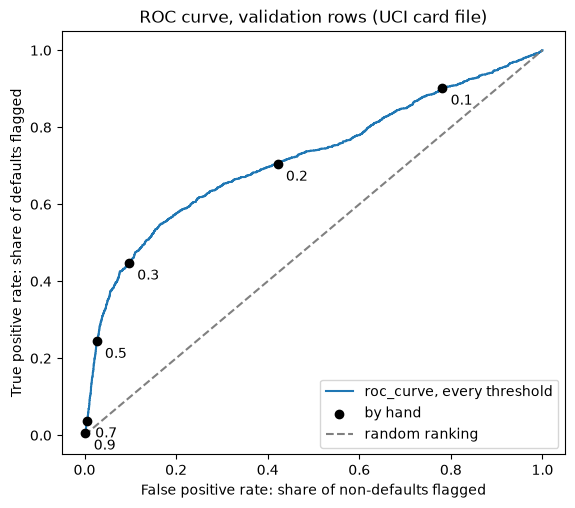

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(fpr, tpr, label="roc_curve, every threshold")
ax.scatter(hand_roc["false positive rate"], hand_roc["true positive rate"], color="black", zorder=3, label="by hand")
for _, row in hand_roc.iterrows():
    ax.annotate(f"{row['threshold']}", (row["false positive rate"], row["true positive rate"]),
                textcoords="offset points", xytext=(6, -12))
# the diagonal: a score that ranks accounts at random
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="random ranking")
ax.set_title("ROC curve, validation rows (UCI card file)")
ax.set_xlabel("False positive rate: share of non-defaults flagged")
ax.set_ylabel("True positive rate: share of defaults flagged")
ax.legend(loc="lower right")
plt.show()

* Moving along the curve from the bottom left is lowering the threshold. The curve bows above the dashed diagonal: at every threshold, the model flags a larger share of the defaults than of the non-defaults.
* The **diagonal** is what a score with no information gives: flag a random 30 percent of accounts and you catch about 30 percent of the defaults and 30 percent of the rest.

## 8.2 AUC as a Ranking Measure

The **area under the ROC curve**, AUC, sums the whole curve into one number between 0 and 1. The diagonal has an area of 0.5; a score that put every default above every non-default would have 1. The course uses ROC AUC on validation rows to compare models, because it needs no threshold.

Q. What is the model's ROC AUC on the validation rows?

In [13]:
from sklearn.metrics import roc_auc_score

# on probabilities, never on 0/1 flags
auc_valid = roc_auc_score(y_valid, proba_valid)
print(f"ROC AUC on the validation rows: {auc_valid:.4f}")

ROC AUC on the validation rows: 0.7190


Q. AUC has a plain reading: pick one account that defaulted and one that did not; AUC is the chance the model gives the defaulted account the higher probability. Check it on every pair of validation accounts.

In [14]:
# the probabilities of the accounts that defaulted, and of those that did not
defaulted = proba_valid[y_valid.to_numpy() == 1]
did_not = proba_valid[y_valid.to_numpy() == 0]

# compare every defaulted account with every other one: a pair counts 1 if the defaulted account scores
# higher, a half if the two probabilities are equal
higher = (defaulted[:, None] > did_not[None, :]).mean()
tied = (defaulted[:, None] == did_not[None, :]).mean()
share_ranked = higher + tied / 2

print(f"{len(defaulted):,} x {len(did_not):,} = {len(defaulted) * len(did_not):,} pairs")
print(f"share of pairs ranked the right way: {share_ranked:.4f}")
print(f"equal to roc_auc_score within 1e-12: {abs(share_ranked - auc_valid) < 1e-12}")

1,327 x 4,673 = 6,201,071 pairs
share of pairs ranked the right way: 0.7190
equal to roc_auc_score within 1e-12: True


* 6,201,071 pairs, and in 71.90% of them the defaulted account has the higher probability. That is the AUC, 0.7190: a measure of **ranking**.

**What AUC does not say.** It is not an accuracy, not a default rate, and not a probability that any account defaults. It says nothing about how many defaults are caught, or how many false flags come with them, at any threshold the desk would use: it averages over every threshold, including ones nobody would choose. And because it only uses the order of the probabilities, it cannot tell whether the probabilities themselves are right.

Q. Prove the last point: change every probability without changing their order, and compute AUC again. Then compute it on day 7's 0/1 flags, the mistake the convention forbids.

In [15]:
# squaring keeps the order of numbers between 0 and 1, but changes every probability
print(f"ROC AUC of the probabilities squared: {roc_auc_score(y_valid, proba_valid ** 2):.4f}")
print(f"largest change in a probability from squaring: {np.max(proba_valid - proba_valid ** 2):.4f}")

# the flags at 0.5 keep only two values, so most of the ranking is thrown away
print(f"ROC AUC of the 0/1 flags at 0.5: {roc_auc_score(y_valid, flag_05):.4f}")

ROC AUC of the probabilities squared: 0.7190
largest change in a probability from squaring: 0.2500
ROC AUC of the 0/1 flags at 0.5: 0.6089


* Squared, the probabilities change by up to a quarter, and the AUC is still 0.7190. AUC cannot see whether a probability of 0.3 means three in ten; section 8.6 checks that separately.
* On the 0/1 flags `roc_auc_score` runs without complaint and returns 0.6089, a different number: the area under a curve with one bend, the threshold 0.5. That is why the course computes ROC AUC on probabilities, never on flags.

## 8.3 The Precision-Recall Curve and Average Precision

The false positive rate divides by the 4,673 accounts that did not default, so a few hundred false flags barely move it. The desk's question is usually the other one: **of the accounts flagged, how many defaulted?** That is precision. The **precision-recall curve** plots precision against recall, one point per threshold. Its floor is the default rate itself, 22.12% here: flag every account and that is the share of flagged accounts that defaulted.

Q. Draw the precision-recall curve, with day 7's threshold marked.

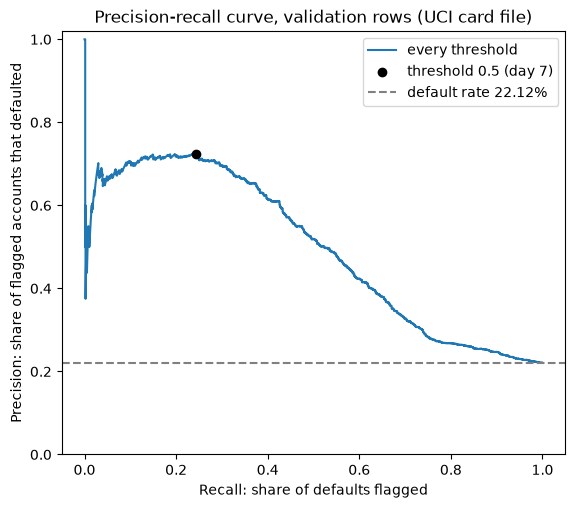

In [16]:
from sklearn.metrics import average_precision_score, precision_recall_curve

# precision and recall at every distinct probability; the last point (recall 0, precision 1) has no threshold
precision, recall, pr_thresholds = precision_recall_curve(y_valid, proba_valid)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(recall, precision, label="every threshold")
ax.scatter([metrics_05["recall"]], [metrics_05["precision"]], color="black", zorder=3, label="threshold 0.5 (day 7)")
# the floor: flag every account and precision is the default rate
ax.axhline(y_valid.mean(), color="grey", linestyle="--", label=f"default rate {y_valid.mean():.2%}")
ax.set_title("Precision-recall curve, validation rows (UCI card file)")
ax.set_xlabel("Recall: share of defaults flagged")
ax.set_ylabel("Precision: share of flagged accounts that defaulted")
ax.set_ylim(0, 1.02)
ax.legend(loc="upper right")
plt.show()

* At the far left only a handful of accounts are flagged, so precision jumps around: one account more or less moves it a lot. From there precision holds near 0.7248 up to about day 7's recall of 0.2442, then slides toward the dashed floor as the threshold falls and more of the flagged accounts are ones that did not default.
* Day 7's threshold sits near the top of the curve: about the best precision on offer, and 76% of the defaults missed.

Q. Sum the curve into one number: average precision.

In [17]:
ap_valid = average_precision_score(y_valid, proba_valid)

# scikit-learn's average precision is a step sum: each rise in recall times the precision at that threshold
step_sum = np.sum(-np.diff(recall) * precision[:-1])

print(f"average precision: {ap_valid:.4f}")
print(f"the step sum by hand equals it within 1e-12: {abs(step_sum - ap_valid) < 1e-12}")

average precision: 0.4946
the step sum by hand equals it within 1e-12: True


* Average precision is 0.4946, against a floor of 0.2212 for a score with no information. It is the area under the precision-recall curve **as scikit-learn computes it**: a sum of steps, each rise in recall times the precision at that threshold, not a trapezoid between points. A trapezoid over the same points (`sklearn.metrics.auc(recall, precision)`) gives 0.4940, a different number, and the course does not use it.
* ROC AUC and average precision answer different questions. AUC is about ranking defaults above non-defaults; average precision is about how clean the flagged list is as it grows. When defaults are rare, average precision is the stricter of the two, which is why the capstone, on a file with far fewer defaults, uses it first.

## 8.4 Choosing a Threshold on Validation Rows

Every threshold is a different trade: more defaults caught, more accounts flagged that did not default. Choosing one needs a rule written down **before** looking, and rows that will not be used to report the result.

**The course's rule.** If the desk asked for a recall of 70 percent, take **the highest threshold whose recall on the validation rows is at least 0.70**. A higher threshold flags fewer accounts, so this is the threshold that meets the target with the fewest flags. The rule and the 0.70 are the course's teaching convention, chosen to make the recall-against-precision choice explicit and testable. They are not a lending standard, and no threshold, recall target, or cost in this course is a statement of what a lender does or should do.

Q. Add `threshold_for_recall` to `mlkit.py`. Read the docstring first: inputs, output, convention, and what raises.

In [18]:
%%writefile -a mlkit.py


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])

Appending to mlkit.py


* The function sorts the rows from the highest probability down. Lowering the threshold flags rows in that order, so the running count of defaults caught gives the recall at every threshold. Rows with equal probabilities are flagged together, so only the last row of each run of ties is a possible threshold.
* It reuses two of the module's helpers: `_as_1d_array` from day 1 and `_check_labels` from day 7.

Q. Add the four tests: a hand case with ties, the target is met, the threshold is the highest that meets it, and bad targets raise.

In [19]:
%%writefile -a test_mlkit.py


from sklearn.metrics import roc_curve


def card_split() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """The card file's 60/20/20 split, stratified, seed 42: 18,000 training, 6,000 validation, 6,000 test rows.
    The four person columns (SEX, EDUCATION, MARRIAGE, AGE) and ID are never features."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    features = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
        [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
    X, y = card[features], card[CARD_TARGET]
    X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=SEED)
    return X_train, X_valid, X_test, y_train, y_valid, y_test


def validation_proba() -> tuple[pd.Series, np.ndarray]:
    """Validation outcomes and probabilities of a scaled logistic regression fitted on the training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    return y_valid, model.predict_proba(X_valid)[:, 1]


def test_threshold_for_recall_hand():
    y = [1, 0, 1, 0, 1, 0]
    proba = [0.9, 0.8, 0.7, 0.4, 0.3, 0.1]
    # at 0.7 two of three defaults are caught (recall 2/3); at 0.3 all three
    assert mlkit.threshold_for_recall(y, proba, 0.6) == 0.7
    assert mlkit.threshold_for_recall(y, proba, 0.7) == 0.3
    assert mlkit.threshold_for_recall(y, proba, 1.0) == 0.3
    # tied probabilities are flagged together
    assert mlkit.threshold_for_recall([1, 1, 0, 1], [0.6, 0.5, 0.5, 0.2], 0.5) == 0.5


def test_threshold_meets_target():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    recall = mlkit.classification_metrics(y_valid, (proba >= threshold).astype(int))["recall"]
    assert recall >= 0.70
    # roc_curve flags rows with score >= threshold too: the true positive rate there is the same recall
    # (drop_intermediate=False keeps every distinct probability as a threshold)
    fpr, tpr, thresholds = roc_curve(y_valid, proba, drop_intermediate=False)
    assert tpr[thresholds == threshold][0] == pytest.approx(recall, abs=1e-12)


def test_threshold_is_highest():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    higher = np.unique(proba[proba > threshold])
    # the next distinct probability above the threshold misses the target
    next_up = higher.min()
    assert mlkit.classification_metrics(y_valid, (proba >= next_up).astype(int))["recall"] < 0.70


def test_threshold_rejects_bad_target():
    for target in (0.0, -0.1, 1.2):
        with pytest.raises(ValueError):
            mlkit.threshold_for_recall([0, 1], [0.2, 0.8], target)
    with pytest.raises(ValueError, match="no row of class 1"):
        mlkit.threshold_for_recall([0, 0], [0.2, 0.8], 0.5)

Appending to test_mlkit.py


* `card_split` and `validation_proba` rebuild today's split and model inside the tests, so the tests do not depend on the notebook's variables. `test_threshold_meets_target` also checks that `roc_curve` gives the same recall at that threshold.

Q. Reload the module and run every test.

In [20]:
# the file changed, so reload before using the new function
importlib.reload(mlkit)
print(f"threshold_for_recall in mlkit: {hasattr(mlkit, 'threshold_for_recall')}")

threshold_for_recall in mlkit: True


In [21]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...................................                                      [100%]
35 passed in 2.69s



* Every test passes: today's four and every test from days 1 to 7.

Q. Choose the threshold for a recall of 0.70 on the validation rows.

In [22]:
# the course's rule, on the validation rows
threshold_70 = mlkit.threshold_for_recall(y_valid, proba_valid, 0.70)
flag_70 = (proba_valid >= threshold_70).astype(int)
counts_70 = mlkit.confusion_counts(y_valid, flag_70)
metrics_70 = mlkit.classification_metrics(y_valid, flag_70)

print(f"threshold for recall 0.70: {threshold_70:.4f}")
print(counts_70)
print({name: round(value, 4) for name, value in metrics_70.items()})

threshold for recall 0.70: 0.2025
{'tn': 2759, 'fp': 1914, 'fn': 398, 'tp': 929}
{'accuracy': 0.6147, 'precision': 0.3268, 'recall': 0.7001, 'f1': 0.4456}


* The threshold is 0.2025. Flagged at that threshold, 2,843 accounts are flagged, 929 of the 1,327 defaults are caught (recall 0.7001), and 0.3268 of the flagged accounts defaulted. Against day 7's 0.5: 605 more defaults caught, at the cost of 1,791 more accounts flagged that did not default.
* At the next distinct probability above it, recall would be 0.6993, below the target: that is what "highest" means.

**Youden's J**, another published rule, picks the threshold where the true positive rate minus the false positive rate is largest: the point of the ROC curve farthest above the diagonal. It needs no target, which is both its appeal and its limit: it weighs a missed default and a false flag as equal.

Q. Find Youden's threshold and put the three thresholds side by side.

In [23]:
# Youden's J at every threshold from roc_curve; argmax takes the first maximum, the highest threshold if tied
youden_j = tpr - fpr
threshold_youden = thresholds[np.argmax(youden_j)]
print(f"Youden's threshold: {threshold_youden:.4f}, where J = {youden_j.max():.4f}")

# the three thresholds on the validation rows
comparison = {}
for rule, threshold in [("day 7: 0.5", 0.5), ("recall at least 0.70", threshold_70), ("Youden's J", threshold_youden)]:
    flags = (proba_valid >= threshold).astype(int)
    metrics = mlkit.classification_metrics(y_valid, flags)
    comparison[rule] = {"threshold": threshold, "flagged": int(flags.sum()), "flag rate": flags.mean(),
                        "recall": metrics["recall"], "precision": metrics["precision"], "accuracy": metrics["accuracy"]}
# one row per rule; from_dict keeps the counts as whole numbers
comparison = pd.DataFrame.from_dict(comparison, orient="index")
print(f"accuracy of flagging nothing (the all-zero baseline): {1 - y_valid.mean():.4f}")
comparison.round(4)

Youden's threshold: 0.2475, where J = 0.3829
accuracy of flagging nothing (the all-zero baseline): 0.7788


,threshold,flagged,flag rate,recall,precision,accuracy
day 7: 0.5,0.5000,447,0.0745,0.2442,0.7248,0.8123
recall at least 0.70,0.2025,2843,0.4738,0.7001,0.3268,0.6147
Youden's J,0.2475,1507,0.2512,0.5494,0.4837,0.7707


* Youden's threshold is 0.2475, above the recall rule's 0.2025: it flags 1,507 accounts and catches 0.5494 of the defaults, short of the 0.70 the desk asked for, with precision 0.4837. Neither rule is right in general. Youden's answers "where is the curve farthest from random?"; the course's answers "what is the fewest flags that catch 70 percent?". Which question matters is the desk's call, made before looking.
* **Accuracy** is printed beside the all-zero baseline, 0.7788: the model at 0.5 beats it, and at the two lower thresholds it falls below it, because many more non-defaults are flagged. Accuracy is never used to choose. The question on this file is how many defaults are caught, and at what cost in false flags.

Q. Draw the trade-off: recall and precision against the threshold, with the three choices marked.

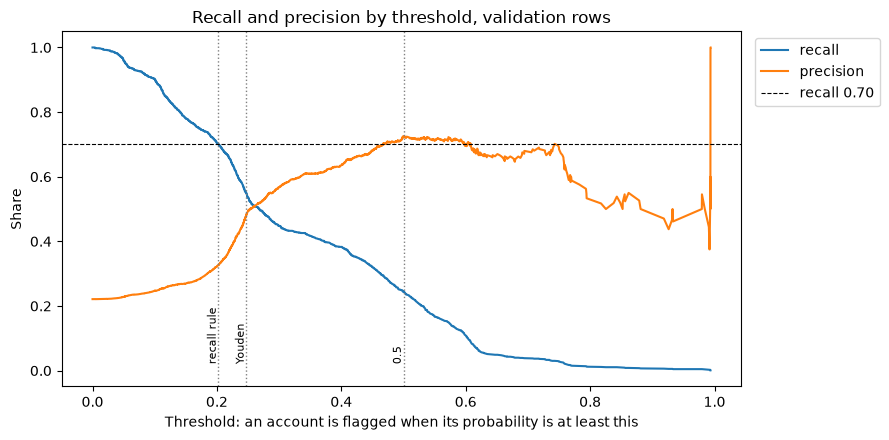

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.5))
# precision_recall_curve gives one more precision and recall than thresholds: drop the last point
ax.plot(pr_thresholds, recall[:-1], label="recall")
ax.plot(pr_thresholds, precision[:-1], label="precision")
# a short label beside each of the three thresholds
short_labels = {"day 7: 0.5": "0.5", "recall at least 0.70": "recall rule", "Youden's J": "Youden"}
for rule, row in comparison.iterrows():
    ax.axvline(row["threshold"], color="grey", linestyle=":", linewidth=1)
    ax.annotate(short_labels[rule], (row["threshold"], 0.02), rotation=90, fontsize=8, ha="right", va="bottom")
ax.axhline(0.70, color="black", linewidth=0.8, linestyle="--", label="recall 0.70")
ax.set_title("Recall and precision by threshold, validation rows")
ax.set_xlabel("Threshold: an account is flagged when its probability is at least this")
ax.set_ylabel("Share")
# the legend outside the plot, so it covers no line
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

* Reading from the right: at high thresholds few accounts are flagged, so recall is low and precision jumps, resting on few accounts. Moving left, recall climbs and precision falls. The course's rule walks left from the top until recall first reaches the dashed line, and stops.

## 8.5 Why the Test Rows Are Not Used to Choose

The validation rows chose the threshold, so their recall of 0.7001 is no longer a fair report: the threshold was picked to make that number at least 0.70. Rows that choose a setting always look good on it. That is why a third set of rows exists. If the threshold were chosen on the test rows, the reported recall would be at least 0.70 by construction, a promise kept by the method rather than a measurement. Choosing on the test rows is leakage, of the quietest kind: no row moves, only a decision.

Q. Show it without touching the test rows. Cut the validation rows in half twenty times; each time, choose the threshold on one half and measure recall on both.

In [25]:
from sklearn.model_selection import StratifiedShuffleSplit

# twenty different halves of the validation rows, each stratified by the outcome
halves = StratifiedShuffleSplit(n_splits=20, test_size=0.5, random_state=SEED)
rows = []
for choose, check in halves.split(X_valid, y_valid):
    # choose on one half
    threshold = mlkit.threshold_for_recall(y_valid.iloc[choose], proba_valid[choose], 0.70)
    # measure recall on the half that chose, and on the half that did not
    rows.append({
        "threshold": threshold,
        "recall on the half that chose": mlkit.classification_metrics(
            y_valid.iloc[choose], (proba_valid[choose] >= threshold).astype(int))["recall"],
        "recall on the other half": mlkit.classification_metrics(
            y_valid.iloc[check], (proba_valid[check] >= threshold).astype(int))["recall"],
    })
halves_table = pd.DataFrame(rows)
print(f"other half below 0.70: {(halves_table['recall on the other half'] < 0.70).sum()} of {len(halves_table)}")
halves_table.agg(["min", "max"]).round(4)

other half below 0.70: 15 of 20


,threshold,recall on the half that chose,recall on the other half
min,0.1941,0.7003,0.6395
max,0.2160,0.7014,0.7376


* On the half that chose, recall is between 0.7003 and 0.7014 every time: never below 0.70, because the rule guarantees it. On the half that did not choose, the same threshold gives anything from 0.6395 to 0.7376, and falls short of 0.70 in 15 of 20 cuts. The threshold itself moves from 0.1941 to 0.2160 with the rows.
* So a number from the rows that chose says only that the rule worked. The honest recall comes from rows that played no part. On day 10 the test rows report, once, with the threshold already fixed on validation rows.

## 8.6 Calibration: Does a 0.3 Mean Three in Ten?

A threshold only uses the order of the probabilities, and so does AUC. A probability can also be read as a number: of the accounts given about 0.3, did about three in ten default? A **calibration curve** checks that. Sort the validation accounts by probability into ten groups of equal size, and plot each group's mean probability against the share of its accounts that defaulted. On the diagonal, the probabilities mean what they say.

Q. Draw the calibration curve for the validation rows, with the ten groups printed.

   mean probability  share that defaulted
0            0.0416                0.1300
1            0.0812                0.1033
2            0.1133                0.1417
3            0.1458                0.1633
4            0.1820                0.0917
5            0.2077                0.1167
6            0.2272                0.1633
7            0.2512                0.2333
8            0.3573                0.3800
9            0.5800                0.6883


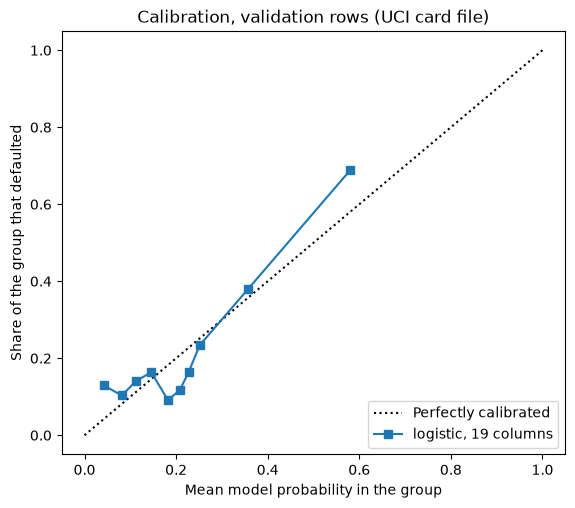

In [26]:
from sklearn.calibration import CalibrationDisplay, calibration_curve

# ten groups of equal size by probability (quantile bins)
share_defaulted, mean_probability = calibration_curve(y_valid, proba_valid, n_bins=10, strategy="quantile")
print(pd.DataFrame({"mean probability": mean_probability, "share that defaulted": share_defaulted}).round(4).to_string())

fig, ax = plt.subplots(figsize=(6.5, 5.5))
CalibrationDisplay.from_predictions(y_valid, proba_valid, n_bins=10, strategy="quantile", ax=ax, name="logistic, 19 columns")
ax.set_title("Calibration, validation rows (UCI card file)")
ax.set_xlabel("Mean model probability in the group")
ax.set_ylabel("Share of the group that defaulted")
plt.show()

* The group nearest 0.3 has a mean probability of 0.2512 and 23.33% of its accounts defaulted: close. Elsewhere the curve leaves the diagonal. In the lowest group the model says 0.0416 on average and 13.00% defaulted; in the group with mean 0.2077, only 11.67% did; in the top group the model says 0.5800 and 68.83% defaulted. 6 of the 10 groups sit above the diagonal and 4 below.
* Each group holds about 600 accounts, so its share carries Course 1's rough margin of 1.96 x sqrt(p(1 - p) / n): about 2.7 points in the lowest group, 2.6 in the group with mean 0.2077, and 3.7 in the top group. The three gaps above are larger than their margins.
* So on these rows the model ranks accounts better than chance (AUC 0.7190), and its probabilities are not uniformly reliable as numbers: a probability of 0.04 or 0.21 does not mean what it says here. Recalibrating a model is Course 5's subject; here the chart is read and described.

## Excel Side by Side

Excel has no ROC or AUC function and no split function. Here the model is fitted in Python, and the 6,000 validation rows are pasted onto a sheet named `valid`: the actual outcome (0 or 1) in column A and the model probability in column B, headers in row 1. Every formula below was typed into Excel by script on those rows (Excel 16.0 build 20430, 2026-10-04).

**A threshold table.** Thresholds in D2:D6 (0.7, 0.5, 0.3, 0.2, 0.1), one row each:

| Column | Python | Excel, row 2 | Excel returned at 0.5 |
| --- | --- | --- | --- |
| Flagged | `(proba_valid >= t).sum()` | `=COUNTIF(B2:B6001,">="&D2)` | 447 |
| TP | `confusion_counts(...)["tp"]` | `=COUNTIFS(A2:A6001,1,B2:B6001,">="&D2)` | 324 |
| FP | `confusion_counts(...)["fp"]` | `=COUNTIFS(A2:A6001,0,B2:B6001,">="&D2)` | 123 |
| Recall, the true positive rate | TP / (TP + FN) | `=F2/COUNTIF(A2:A6001,1)` | 0.2442 |
| False positive rate | FP / (FP + TN) | `=G2/COUNTIF(A2:A6001,0)` | 0.0263 |
| Precision | TP / (TP + FP) | `=F2/E2` | 0.7248 |

All five rows matched section 8.1's hand table exactly.

**The whole curve.** Each distinct probability is a threshold, so the curve needs one row per distinct value. In M3, `=SORT(UNIQUE($B$2:$B$6001),,-1)` spills all 5,882 distinct probabilities, highest first (dynamic arrays). Row 2 holds the starting point, 0 in N2 and O2. Then one formula per column spills down beside them:

* False positive rate in N3: `=COUNTIFS($A$2:$A$6001,0,$B$2:$B$6001,">="&M3#)/COUNTIF($A$2:$A$6001,0)`
* True positive rate in O3: `=COUNTIFS($A$2:$A$6001,1,$B$2:$B$6001,">="&M3#)/COUNTIF($A$2:$A$6001,1)`
* AUC by the trapezoid rule: `=SUMPRODUCT((N3:N5884-N2:N5883),(O3:O5884+O2:O5883)/2)` returned 0.7190. Each step of the false positive rate times the average height of the two points: the area under the curve, strip by strip. Ties need no special handling, because each threshold flags every row with that probability.

**The two rules, and average precision.**

* The course's rule: `=MAXIFS(M3#,O3#,">=0.7")`, the highest threshold whose recall is at least 0.7, returned 0.2025, the same threshold as `threshold_for_recall`. It works because recall only rises as the threshold falls.
* Youden's J: `=INDEX(M3#,MATCH(MAX(O3#-N3#),O3#-N3#,0))` returned 0.2475. `MATCH` finds the first maximum in a column sorted from the highest threshold down, the same choice `np.argmax` makes.
* Precision in P3: `=O3#*COUNTIF($A$2:$A$6001,1)/(O3#*COUNTIF($A$2:$A$6001,1)+N3#*COUNTIF($A$2:$A$6001,0))`; then average precision as a step sum, `=SUMPRODUCT((O3:O5884-O2:O5883),P3:P5884)`, returned 0.4946.

In [27]:
# Excel's numbers on the validation rows, from the day's Excel check, beside Python's
excel_values = {"ROC AUC": 0.7190453874822601, "average precision": 0.49459677703483373,
                "threshold for recall 0.70": 0.20246382321769993, "Youden's threshold": 0.24746342840053667,
                "recall at 0.5": 0.24415975885455915, "precision at 0.5": 0.7248322147651006}
python_values = {"ROC AUC": auc_valid, "average precision": ap_valid, "threshold for recall 0.70": threshold_70,
                 "Youden's threshold": threshold_youden, "recall at 0.5": metrics_05["recall"],
                 "precision at 0.5": metrics_05["precision"]}

side_by_side = pd.DataFrame({"Excel": excel_values, "Python": python_values})
side_by_side["within 1e-9"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-9
side_by_side.round({"Excel": 4, "Python": 4})

,Excel,Python,within 1e-9
ROC AUC,0.7190,0.7190,True
average precision,0.4946,0.4946,True
threshold for recall 0.70,0.2025,0.2025,True
Youden's threshold,0.2475,0.2475,True
recall at 0.5,0.2442,0.2442,True
precision at 0.5,0.7248,0.7248,True


* Every number matches. The threshold table and the two rules are formulas an Excel user can audit cell by cell; the probabilities themselves came from Python, because Excel has no pipeline that scales 19 columns on the training rows and fits a logistic regression.

## Save the Day with Git

The work folder is new today, so it gets a repository, the module is committed, and the experiment log starts again. Today the log records the threshold choices: one row per choice, committed one at a time, so `git log` of the results file reads as the history of what was chosen and in what order. The columns are week 2's, the same as day 7's: the model (here with the rule that chose its threshold), the rows it was scored on, ROC AUC and average precision, the threshold, and the four metrics at that threshold (4 decimals).

Q. Make the work folder a repository, with the same `.gitignore` as every day.

In [28]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [29]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_08_z7a3hm3i and nowhere else


In [30]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


Q. Commit the module and its tests as they stand at the end of today.

In [31]:
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "mlkit: threshold_for_recall, with four tests"
!git -C "{work}" log --oneline

c39d345 mlkit: threshold_for_recall, with four tests


Q. Write the first row of the log, day 7's threshold, and commit it.

In [32]:
def log_row(rule, threshold):
    """One row of the experiment log in week 2's columns: the model and the rule that chose its threshold, the
    rows, the two ranking metrics, the threshold, and the four metrics at that threshold."""
    flags = (proba_valid >= threshold).astype(int)
    metrics = mlkit.classification_metrics(y_valid, flags)
    return {"model": f"logistic_scaled at {rule}", "rows": "validation", "roc_auc": auc_valid,
            "average_precision": ap_valid, "threshold": threshold, **metrics}


log = [log_row("fixed 0.5", 0.5)]
# 4 decimals, so a diff shows a real change and not the last digits of a float
pd.DataFrame(log).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
logistic_scaled at fixed 0.5,validation,0.7190,0.4946,0.5000,0.8123,0.7248,0.2442,0.3653



In [33]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: the logistic model at day 7's threshold 0.5"

Q. Add the threshold chosen by the course's rule, commit; then Youden's, commit.

In [34]:
log.append(log_row("recall at least 0.70", threshold_70))
pd.DataFrame(log).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")

In [35]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: the threshold for recall 0.70, chosen on validation rows"

In [36]:
log.append(log_row("Youden J", threshold_youden))
pd.DataFrame(log).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
logistic_scaled at fixed 0.5,validation,0.7190,0.4946,0.5000,0.8123,0.7248,0.2442,0.3653
logistic_scaled at recall at least 0.70,validation,0.7190,0.4946,0.2025,0.6147,0.3268,0.7001,0.4456
logistic_scaled at Youden J,validation,0.7190,0.4946,0.2475,0.7707,0.4837,0.5494,0.5145



In [37]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: Youden's J threshold beside it, for comparison"

Q. Read the history of the choices: every commit that changed `results.csv`, newest first.

In [38]:
# -- results.csv limits the log to commits that changed that file
!git -C "{work}" log --oneline -- results.csv

ca3125c Experiment log: Youden's J threshold beside it, for comparison
a36a460 Experiment log: the threshold for recall 0.70, chosen on validation rows
b44389c Experiment log: the logistic model at day 7's threshold 0.5


* Three commits, one per choice, and the module's commit is not among them: `-- results.csv` keeps only the commits that touched the log. Each message says what was chosen and on which rows. Months later, this is how you answer "why is the threshold 0.20 and not 0.5?": the log shows the order of the choices and the commit that made each one.

## Bring It Home

Add today's function and tests to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder. The tests read `credit_card_default.csv`, which day 6 copied in; if you skipped day 6, copy it now.

```powershell
Set-Location "$HOME\projects\my_bondmath"
Copy-Item "$HOME\projects\python-fixed-income\data\credit_card_default.csv" .
```

**Step 2.** Paste the code of today's `%%writefile -a mlkit.py` cell (section 8.4), without its first line, at the end of `mlkit.py`; do the same for the `%%writefile -a test_mlkit.py` cell at the end of `test_mlkit.py`. Save both.

**Step 3.** Run the tests. Every test passes.

```powershell
python -m pytest -q test_mlkit.py
```

**Step 4.** Read the change, then commit the code only. Data files are never committed here.

```powershell
git diff --stat
git add mlkit.py test_mlkit.py
git commit -m "mlkit: threshold_for_recall, with four tests"
git log --oneline -3
```

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Build an ROC curve by hand from a few thresholds, and for every threshold with `roc_curve`.
* Read ROC AUC as the share of default and non-default pairs ranked the right way, and say what it does not tell you.
* Draw a precision-recall curve and compute average precision, and say why it is a step sum.
* Choose a threshold on validation rows with `threshold_for_recall`, stated as the course's convention, with Youden's J beside it.
* Explain why the rows that choose a threshold cannot report it, and keep the test rows for one report.
* Read a calibration chart.
* Match the threshold table, the curve's area, and both rules in Excel.
* Use `git log -- results.csv` as the history of the choices.

Tomorrow, day 9, builds decision trees on the same rows: a model made of questions. Trees are compared with today's model by ROC AUC on the validation rows, and pruned by cross-validation inside the training rows.

## Exercises

The exercises use the same UCI card accounts (real data, Taiwan, 2005) and the same 60/20/20 split. Every choice is made on the validation rows. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the file, makes the split, fits the model on the training rows, gives the validation rows their probabilities, and defines `check`, a small function that marks your answers.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# the UCI card accounts and the 19 features (the four person columns are never features)
card = pd.read_csv("credit_card_default.csv")
target = "default payment next month"
features = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
X, y = card[features], card[target]

# the week's 60/20/20 split, stratified
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=SEED)
rows_by_role = {"train": (X_train, y_train), "valid": (X_valid, y_valid), "test": (X_test, y_test)}

# the model of section 8.4, fitted on the training rows; probabilities for the validation rows
model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)
proba_valid = model.predict_proba(X_valid)[:, 1]


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Suppose the desk asked for a recall of 60 percent instead. Choose the threshold with `threshold_for_recall` on the validation rows and store it in **ex1_threshold**, and the precision of the flags at that threshold in **ex1_precision**.

In [40]:
ex1_threshold = ...
ex1_precision = ...

In [41]:
check("Exercise 1 the threshold", ex1_threshold, 0.2338161639872026)
check("Exercise 1 the precision", ex1_precision, 0.423936170212766)

Exercise 1 the threshold: not attempted yet
Exercise 1 the precision: not attempted yet


### Exercise 2

Q. Fit the same pipeline on `PAY_0` alone (the September repayment status), on the training rows, and store its ROC AUC on the validation rows in **ex2_auc**.

In [42]:
ex2_auc = ...

In [43]:
check("Exercise 2 the ROC AUC on PAY_0", ex2_auc, 0.6833767908801561)

Exercise 2 the ROC AUC on PAY_0: not attempted yet


### Exercise 3

Q. Add a function to your module. `youden_threshold(y_true, proba)` returns the threshold where the true positive rate minus the false positive rate is largest, from `roc_curve` with `drop_intermediate=False`, the higher threshold if two tie, and raises `ValueError` if `y_true` does not hold both classes. Write the docstring first. Then add `test_youden_threshold_hand`: for outcomes `[0, 0, 1, 1]` and probabilities `[0.1, 0.4, 0.35, 0.8]`, J is 0.5 at both 0.8 and 0.35, so the answer is 0.8; and outcomes of one class raise. Run pytest, reload the module, and store `mlkit.youden_threshold(y_valid, proba_valid)` in **ex3_threshold**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [44]:
%%writefile -a mlkit.py


# Exercise 3: write youden_threshold(y_true, proba) below this line

Appending to mlkit.py


In [45]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_youden_threshold_hand() below this line

Appending to test_mlkit.py


In [46]:
# run pytest, reload the module, then call your function
ex3_threshold = ...

In [47]:
check("Exercise 3 youden_threshold on the validation rows", ex3_threshold, 0.24746342840053667)

Exercise 3 youden_threshold on the validation rows: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that chooses the threshold by the course's rule, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Choose the threshold for a fitted classifier by the course's rule.

    rows: the course split, a dict of (X, y) pairs under the keys "train", "valid", and "test".
    The threshold is chosen on the validation rows: the training rows fitted the model, and the test rows
    stay put away until they report, once, on day 10.
    Rule: the highest threshold whose recall is at least target_recall (mlkit.threshold_for_recall).
    Returns: the threshold, one of the model's probabilities.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a threshold of the right size, and contains one bug.

In [48]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def choose_threshold(model, rows, target_recall=0.70):
    """Choose the threshold for a fitted classifier by the course's rule.

    rows: the course split, a dict of (X, y) pairs under the keys "train", "valid", and "test".
    The threshold is chosen on the validation rows: the training rows fitted the model, and the test rows
    stay put away until they report, once, on day 10.
    Rule: the highest threshold whose recall is at least target_recall (mlkit.threshold_for_recall).
    Returns: the threshold, one of the model's probabilities.
    """
    # choose on the held-out rows, so the threshold comes from data the model has never seen
    X_choose, y_choose = rows["test"]
    proba = model.predict_proba(X_choose)[:, 1]
    return mlkit.threshold_for_recall(y_choose, proba, target_recall)

Q. Before you run the next cell: will `choose_threshold` return the same threshold as section 8.4's `threshold_for_recall` on the validation rows? The docstring describes exactly section 8.4's choice.

In [49]:
ai_threshold = choose_threshold(model, rows_by_role)
print(f"the same threshold as section 8.4: {ai_threshold == mlkit.threshold_for_recall(y_valid, proba_valid, 0.70)}")

the same threshold as section 8.4: False


Q. Test the function against its docstring before you trust it.

In [50]:
# the test, written from the docstring before the code is trusted
ai_threshold = choose_threshold(model, rows_by_role)

# the threshold the docstring promises: the course's rule on the validation rows
expected = mlkit.threshold_for_recall(y_valid, model.predict_proba(X_valid)[:, 1], 0.70)
assert ai_threshold == expected, "the threshold was not chosen on the validation rows"
print(f"choose_threshold chooses on the validation rows: {ai_threshold:.4f}")

AssertionError: the threshold was not chosen on the validation rows

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's threshold, `choose_threshold(model, rows_by_role)`, in **ex4_threshold**.

In [51]:
# fix the function above and run the test again, then store the answer
ex4_threshold = ...

In [52]:
check("Exercise 4 the fixed function's threshold", ex4_threshold, 0.20246382321769993)

Exercise 4 the fixed function's threshold: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```